In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Charger les fichiers
winners= pd.read_excel("../data/clean data/df_winners_clean.xlsx")
stages= pd.read_excel("../data/clean data/df_stages_cleaned.xlsx")


# Nettoyer les noms des coureurs (retirer le pays entre parenthèses)
stages["Winner_clean"] = stages["Winner"].str.replace(r"\s*\(.*\)", "", regex=True).str.strip()
winners["Rider_clean"] = winners["Rider"].str.strip()



In [2]:
# --- 3. Fusion gagnants
winners["Label"] = 1
df_merged = pd.merge(stages, winners, left_on=["Year", "Winner_clean"], right_on=["Year", "Rider_clean"], how="inner")

# --- 4. Créer des perdants (échantillons négatifs)
losers = winners.sample(n=len(df_merged), replace=True, random_state=42).copy()
losers["Label"] = 0

# --- 5. Combiner gagnants + perdants
df_ml = pd.concat([df_merged, losers], axis=0, ignore_index=True)

In [3]:
le_type = LabelEncoder()
le_country = LabelEncoder()
le_team = LabelEncoder()

df_ml["Type_encoded"] = le_type.fit_transform(df_ml["Type"])
df_ml["Country_encoded"] = le_country.fit_transform(df_ml["Country"])
df_ml["Team_encoded"] = le_team.fit_transform(df_ml["Team"])


In [4]:
features = [
    "Distance(km)", "Avg Speed(km/h)", "Height(m)", "Weight(kg)",
    "Stages Led", "Type_encoded", "Country_encoded", "Team_encoded"
]
X = df_ml[features]
y = df_ml["Label"]


In [5]:
# --- 8. Split & modèle
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

# --- 9. Évaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        64

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129



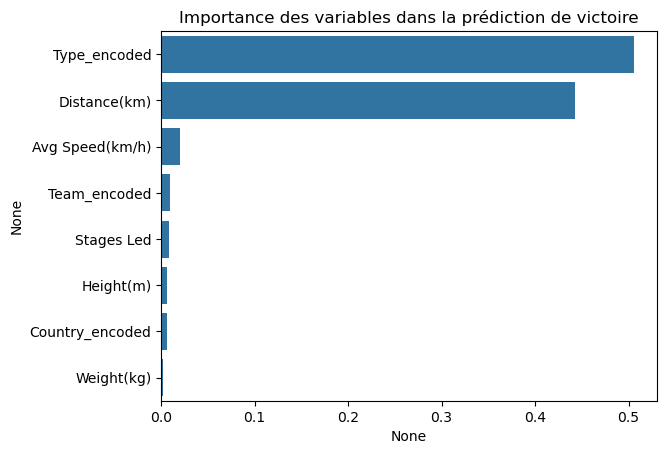

In [6]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances, y=importances.index)
plt.title("Importance des variables dans la prédiction de victoire")
plt.show()


In [8]:
import joblib

# Save your trained model
joblib.dump(model, "winner_prediction_model.pkl")
print("✅ Model saved successfully")
df_ml.to_excel("../data/Results ML/prediction.xlsx" )

✅ Model saved successfully
